In [1]:
from torch_geometric.datasets import TUDataset
from torch_geometric.utils import to_networkx

import networkx as nx
import matplotlib.pyplot as plt

import numpy as np

dataset = TUDataset("./datasets","MUTAG",use_node_attr=True,use_edge_attr=True)
print(dataset)
graphs = [to_networkx(g, node_attrs=["x"],edge_attrs=["edge_attr"],to_undirected=True, remove_self_loops=True) for g in dataset]
y = dataset.y


MUTAG(188)


In [2]:
graphs[0].nodes(data=True)

NodeDataView({0: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 1: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 2: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 3: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 4: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 5: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 6: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 7: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 8: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 9: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 10: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 11: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 12: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 13: {'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 14: {'x': [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, 15: {'x': [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]}, 16: {'x': [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]}})

Node labels:

  0  C
  1  N
  2  O
  3  F
  4  I
  5  Cl
  6  Br

Edge labels:

  0  aromatic
  1  single
  2  double
  3  triple


In [3]:
type(graphs[0].nodes(data=True)[0]['x'])
def convert_node_attr(l):
    attr_table = {0:'C',1:'N',2:'O',3:'F',4:'I',5:'Cl',6:'Br'}
    idx = np.argmax(l)
    return attr_table[idx]
 

In [4]:
   
for g in graphs:
    new_values = {n:convert_node_attr(attr['x']) for n,attr in g.nodes(data=True)}
    nx.set_node_attributes(g, name='atom', values=new_values)

  

In [5]:
graphs[0].nodes(data=True)[13]

{'x': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'atom': 'C'}

In [6]:
from gklearn.kernels import PathUpToH
from gklearn.kernels import Treelet
from gklearn.utils.kernels import gaussian_kernel
import functools


# Initailize parameters for graph kernel computation.
kernel_options = {'depth': 3,'k_func': 'MinMax','compute_method': 'trie'}
# Initialize graph kernel.
graph_kernel = PathUpToH(node_labels=['atom'], # list of node label names.
						 #ds_infos=dataset.get_dataset_infos(keys=['directed']), # dataset information required for computation.
						 **kernel_options, # options for computation.
						 )


# Initailize parameters for graph kernel computation.
kernel_options = {'depth': 3,'k_func': 'MinMax','compute_method': 'trie'}
# Initialize graph kernel.
graph_kernel = PathUpToH(node_labels=['atom'], # list of node label names.
						 #ds_infos=dataset.get_dataset_infos(keys=['directed']), # dataset information required for computation.
						 **kernel_options, # options for computation.
						 )

graph_kernel = Treelet(node_labels=['atom'], # list of node label names.)
                       sub_kernel = functools.partial(gaussian_kernel, gamma=0.0001) , # Sub-kernel for computing treelet kernel.
                       ds_infos = {'directed': False}, # dataset information required for computation.
								)

print('done.')

import multiprocessing
import matplotlib.pyplot as plt

# Compute Gram matrix.
gram_matrix, run_time = graph_kernel.compute(graphs)
# Print results.

done.
getting canonkeys: 188it [00:00, 555.75it/s]
Computing kernels: 17766it [00:03, 4952.13it/s]
Gram matrix of size 188 built in 4.310747385025024 seconds.


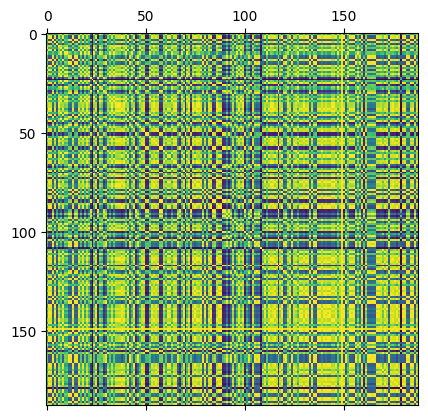

In [7]:
%matplotlib inline 
plt.matshow(gram_matrix)


In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit

# Split dataset into training and test sets.
idx = np.arange(len(y))
n_splits = 1  # Nombre de splits (1 signifie une seule division en ensembles)
test_size = 0.3  # Par exemple, pour un ensemble de test de 20%
random_state = 42  # Pour la reproductibilité

# Créez un objet ShuffleSplit
ss = ShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=random_state)

# Utilisez la méthode split pour obtenir les index des ensembles d'entraînement et de test
for train_index, test_index in ss.split(idx):
    idx_train = train_index
    idx_test = test_index

X_train = gram_matrix[idx_train][:,idx_train]
y_train = y[idx_train]
X_test = gram_matrix[idx_test][:,idx_train]
y_test = y[idx_test]



In [9]:
svc = SVC(kernel='precomputed',C=10)
svc.fit(X_train, y_train)
print('done.')

# Evaluate model.
print('Train score: {:.2f}'.format(svc.score(X_train, y_train)))
print('Test score: {:.2f}'.format(svc.score(X_test, y_test)))


done.
Train score: 0.84
Test score: 0.93


In [10]:
print(svc.predict(X_test))

[1 1 0 1 1 1 1 0 0 0 1 0 1 0 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 0
 0 0 1 0 0 1 1 1 1 0 1 1 1 0 1 1 0 1 1 0]


In [11]:
import functools
from gklearn.utils.kernels import gaussian_kernel

gkernel = functools.partial(gaussian_kernel, gamma=0.0001) 


In [12]:
gkernel

functools.partial(<function gaussian_kernel at 0x7efe7b93b010>, gamma=0.0001)

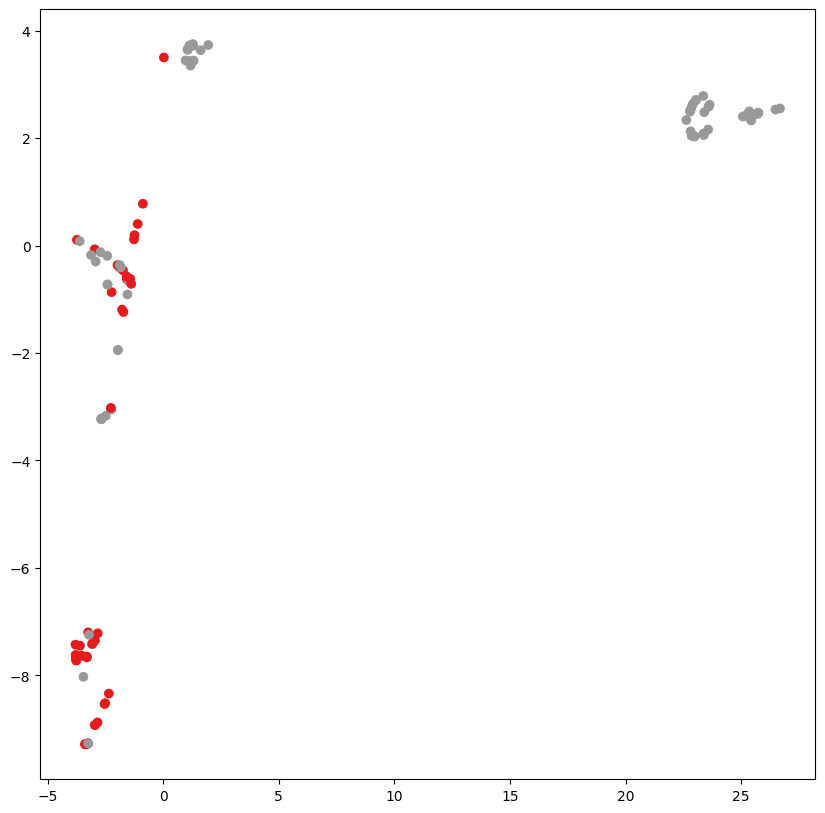

In [13]:
from sklearn.manifold import TSNE

# Compute TSNE embedding.   
X_embedded = TSNE(n_components=2).fit_transform(X_train)

# Plot TSNE embedding.
plt.figure(figsize=(10,10))
plt.scatter(X_embedded[:,0], X_embedded[:,1], c=y_train, cmap='Set1')
plt.show()
